# Base Model Notebook

The goal of this notebook is to build a model from scratch and identify key components and insights that will be useful for developing more complex models.

### Imports

In [13]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, RandAugment, GlobalAveragePooling2D, GlobalMaxPool2D, Dropout, RandomRotation, RandomFlip, BatchNormalization, Activation
from keras.optimizers import SGD, Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import EarlyStopping

#Model Class
from keras import Model

#Our custom augmentations
from augmentation import (
    augmentation_conservative,
    augmentation_mild,
    augmentation_moderate,
    augmentation_moderate_plus,
    augmentation_aggressive,
    augmentation_moderate_noise,
)

In [2]:
Train_Path = "Data/Train"
Validation_Path = "Data/Validation"

Input_shape = (124,124,3) #We will use 124 x 124 just because we are testing and we want the training to be faster
Batch_size = 64

We will define our evaluation metrics right now, so we don't have to define it in each model created

In [3]:

# metrics
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")
metrics = [categorical_accuracy, auc, f1_score]

Importing the Train and Validation set

In [4]:
train_df = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (124,124),
    batch_size=Batch_size,
    seed=42
)

Found 9329 files belonging to 23 classes.


In [5]:
val_df = image_dataset_from_directory(
    Validation_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (124,124),
    batch_size=Batch_size,
    seed=42
)

Found 1999 files belonging to 23 classes.


## First Model

In [11]:
class First_Model(Model):
    """
    A First model, with a very simple arquitecture that we can build on.
    It has 2 convolutional Blocks with 2 Max Pooling layers, a Flatten layer and 2 Dense Layers

    """
    #Initialization
    def __init__(self):
        super().__init__(name="First_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Flatten_layer = Flatten()
        self.Dense_1 = Dense(100, activation="relu")
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Flatten_layer(x)                                       
        x = self.Dense_1(x)
        x = self.Dense_2(x)

        return x

In [21]:
#Get the summary of the model

first_model = First_Model()
inputs = Input(shape=Input_shape)
_ = first_model.call(inputs)
first_model.summary()

Model: "First_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20184)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │     2,018,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,026,703 (7.73 MB)

 Trainable params: 2,026,703 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Defining the optimizer, the loss and the number of epochs

optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [23]:
first_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [ ]:
first_model_results = first_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)


Epoch 1/20


I0000 00:00:1776723493.443135   24750 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19156__.47


143/146 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2804 - auc: 0.7991 - f1_score: 0.2540 - loss: 3.0638

I0000 00:00:1776723497.380956   24747 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19156__.47


146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.2280 - auc: 0.7505 - f1_score: 0.1948 - loss: 3.0168 - val_accuracy: 0.1191 - val_auc: 0.6621 - val_f1_score: 0.0224 - val_loss: 2.9660
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1659 - auc: 0.6908 - f1_score: 0.0489 - loss: 2.8821 - val_accuracy: 0.1561 - val_auc: 0.6985 - val_f1_score: 0.0470 - val_loss: 2.8651
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1944 - auc: 0.7290 - f1_score: 0.0879 - loss: 2.7807 - val_accuracy: 0.1846 - val_auc: 0.7341 - val_f1_score: 0.0870 - val_loss: 2.7698
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2244 - auc: 0.7641 - f1_score: 0.1256 - loss: 2.6707 - val_accuracy: 0.2246 - val_auc: 0.7592 - val_f1_score: 0.1459 - val_loss: 2.6848
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2543 - auc: 0.7897 - f1_score: 0.1628 - loss: 2.5581 - val_accuracy: 0.2411 - val_auc: 0.7754 - val_f1_score: 0.1624 - val_loss: 2.6

In [11]:
#Function to plot the metrics for better evaluation
def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0,0].set_ylim(bottom=0)
    axes[0, 0].legend()

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0,1].set_ylim(bottom=0)
    axes[0, 1].legend()

    # F1 Score
    axes[1, 0].plot(history.history['f1_score'], label='Train')
    axes[1, 0].plot(history.history['val_f1_score'], label='Val')
    axes[1, 0].set_title('F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1,0].set_ylim(bottom=0)
    axes[1, 0].legend()

    # AUC
    axes[1, 1].plot(history.history['auc'], label='Train')
    axes[1, 1].plot(history.history['val_auc'], label='Val')
    axes[1, 1].set_title('AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1,1].set_ylim(bottom=0)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

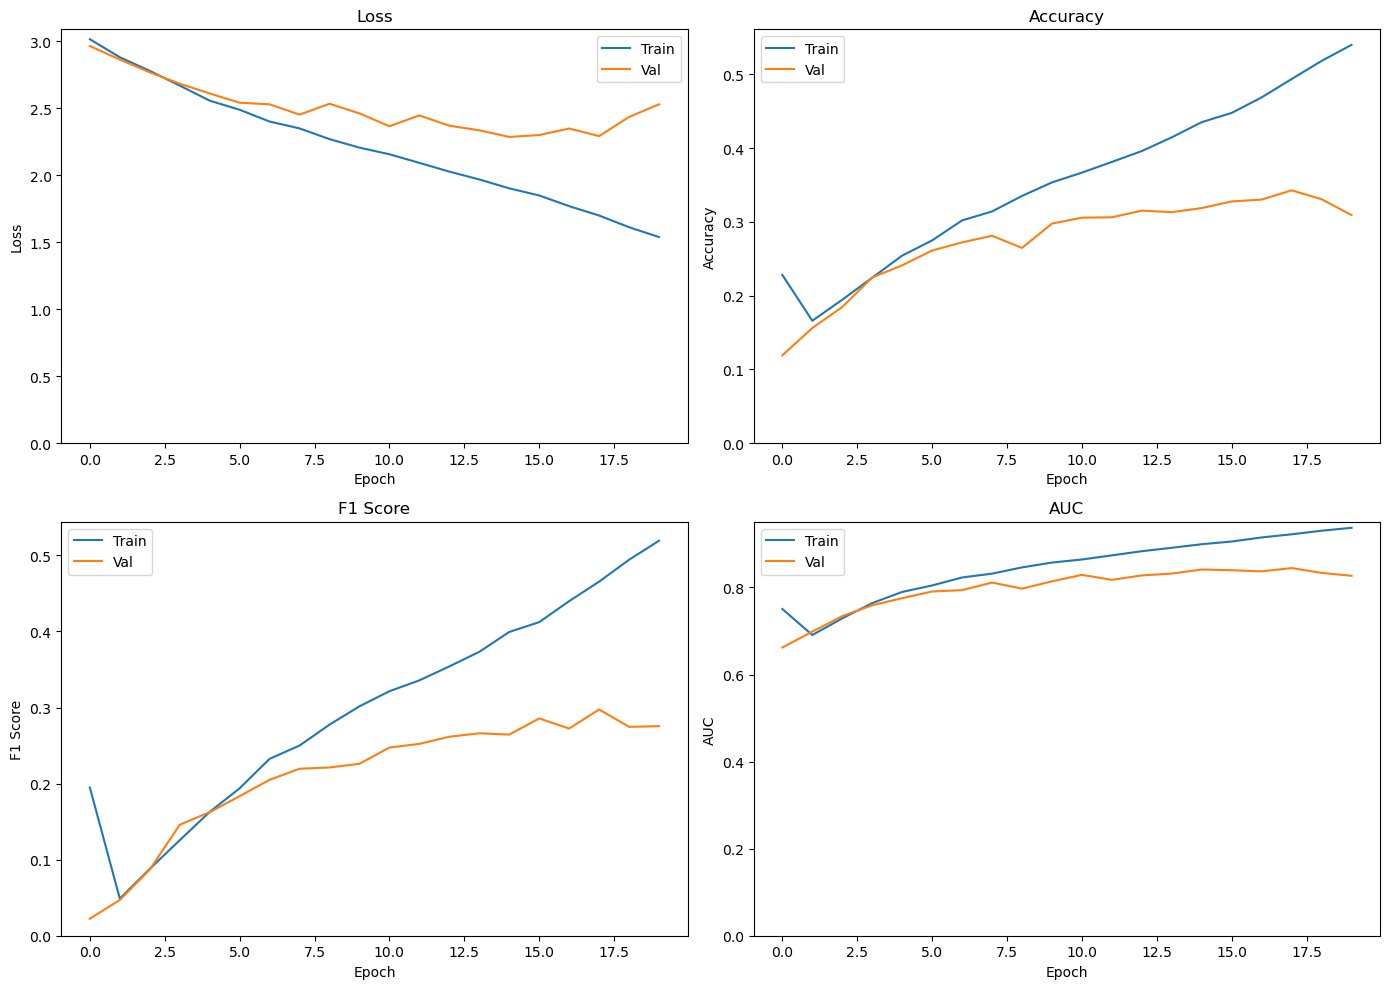

In [26]:
plot_history(first_model_results)

The results were as expected, the f1 score was not the best in train and val even with 20 epochs. The model also overfitted a lot, in the last 3 epochs the models could not reduse loss.

In the next step in order to try to increase performance and for the model to converge faster, we decided to switch the optimizer to Adam.

## First Model with Adam

In [36]:
first_model_adam = First_Model()


In [37]:
#We will decrease the learning rate because Adam is much more sensitive than SGD
optimizer= Adam(learning_rate=0.001, name="optimizer")

In [38]:
first_model_adam.compile(optimizer=optimizer,loss=loss,metrics=metrics)

In [ ]:
first_model_adam_results = first_model_adam.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20


I0000 00:00:1776724663.425165   24746 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99698__.47


142/146 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1372 - auc: 0.6557 - f1_score: 0.0494 - loss: 2.9332

I0000 00:00:1776724667.650173   24745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99698__.47


146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.1755 - auc: 0.7033 - f1_score: 0.0866 - loss: 2.7683 - val_accuracy: 0.2711 - val_auc: 0.7763 - val_f1_score: 0.1713 - val_loss: 2.5830
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3252 - auc: 0.8344 - f1_score: 0.2653 - loss: 2.3282 - val_accuracy: 0.3167 - val_auc: 0.8247 - val_f1_score: 0.2543 - val_loss: 2.3679
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4130 - auc: 0.8840 - f1_score: 0.3693 - loss: 2.0113 - val_accuracy: 0.3487 - val_auc: 0.8446 - val_f1_score: 0.2922 - val_loss: 2.2617
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5001 - auc: 0.9206 - f1_score: 0.4687 - loss: 1.7038 - val_accuracy: 0.3337 - val_auc: 0.8392 - val_f1_score: 0.3045 - val_loss: 2.3523
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5905 - auc: 0.9501 - f1_score: 0.5705 - loss: 1.3768 - val_accuracy: 0.3467 - val_auc: 0.8369 - val_f1_score: 0.3044 - val_loss: 2.4

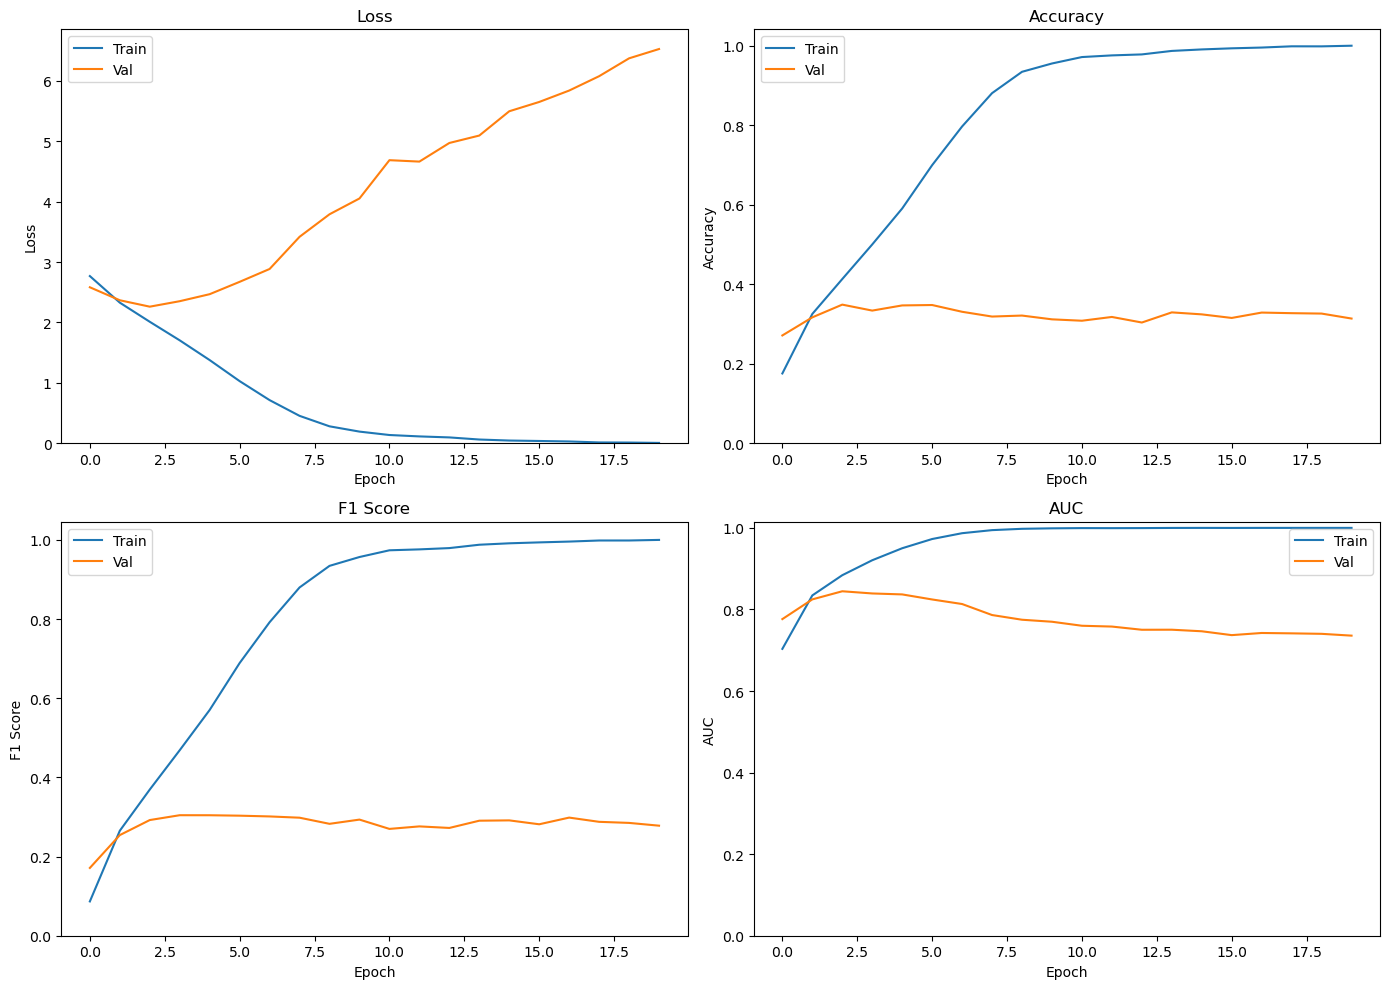

In [40]:
plot_history(first_model_adam_results)

The performance of the model generaly improved, and the model converged ultra fast, but we have a lot of over fitting, the scores are very high in the training set and very bad in the validation data set, so we have to do something about it.

In the next setp we will try adding augmentations and drop out in order to reduce overfitting

## Base model with Augmentations and Dropout

In [55]:
class Augmented_Model(Model):
    """
    Using augmentation techniques and dropout to reduce overfitting.

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Augmented_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Flatten_layer = Flatten()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Flatten_layer(x)                                       
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [56]:
#Get the summary of the model

Augmented_Model = Augmented_Model()
inputs = Input(shape=Input_shape)
_ = Augmented_Model.call(inputs)
Augmented_Model.summary()

Model: "Augmented_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 20184)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │     2,018,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,026,703 (7.73 MB)

 Trainable params: 2,026,703 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
optimizer = Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [58]:
Augmented_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [59]:
Augmented_Model_results = Augmented_Model.fit(
    train_df,
    validation_data= val_df,
    epochs=epochs
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2003 - auc: 0.7202 - f1_score: 0.1375 - loss: 2.8879 - val_accuracy: 0.2076 - val_auc: 0.7501 - val_f1_score: 0.1214 - val_loss: 2.7319
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.2515 - auc: 0.7918 - f1_score: 0.1792 - loss: 2.5511 - val_accuracy: 0.2576 - val_auc: 0.7962 - val_f1_score: 0.2007 - val_loss: 2.5242
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.3040 - auc: 0.8252 - f1_score: 0.2436 - loss: 2.3861 - val_accuracy: 0.2726 - val_auc: 0.8105 - val_f1_score: 0.2135 - val_loss: 2.4561
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3219 - auc: 0.8440 - f1_score: 0.2682 - loss: 2.2849 - val_accuracy: 0.3017 - val_auc: 0.8263 - val_f1_score: 0.2419 - val_loss: 2.3807
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3434 - auc: 0.8573 - f1_score: 0.2936 - loss: 2.2046 - val_accuracy: 0.3127 - val_auc: 0.8353 - val_f1_score: 0.2753 - va

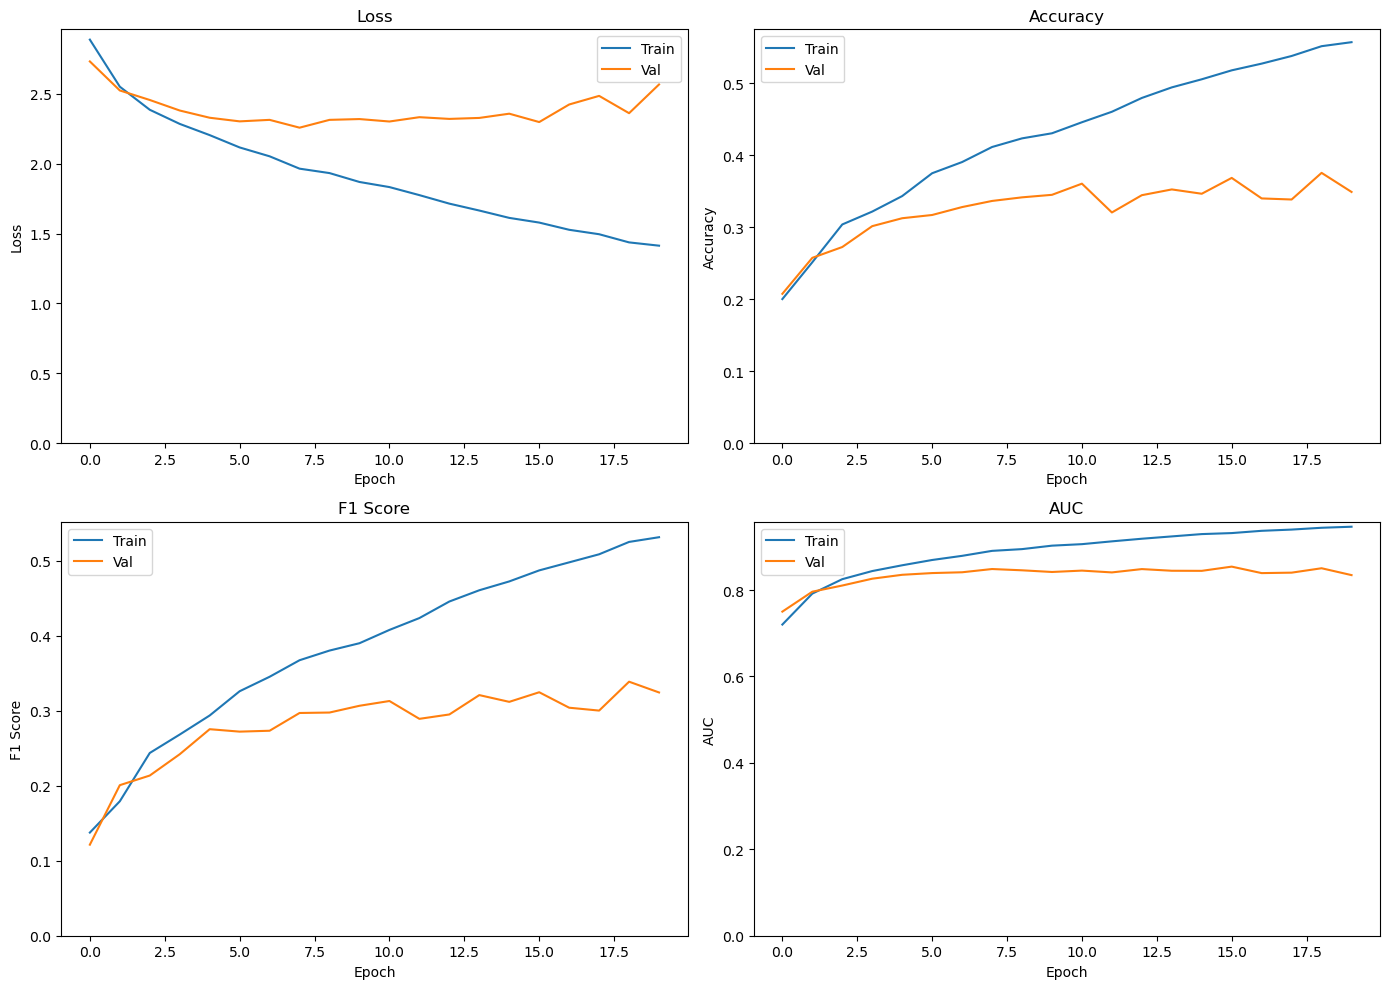

In [60]:
plot_history(Augmented_Model_results)

After looking at the plots, we can see that we reduced the overfitting as me wanted, so we will hold the augmentations and the dropout for the future models, but there is still room from improvement.
We spotted that we have a lot of parameters because we are using flatten and this can be another cause for overfitting.

Next we will switch Flatten to GlobalaveragePooling2D to resolve this issue.

## Base Model with GlobalAveragePooling2D

In [8]:
class Globalaveragepooling_Model(Model):
    """
    Switching Flatten to Globalaveragepooling to reduce the number of parameters

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Globalaveragepooling_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [9]:
Globalaveragepooling_Model = Globalaveragepooling_Model()
inputs = Input(shape=Input_shape)
_ = Globalaveragepooling_Model.call(inputs)
Globalaveragepooling_Model.summary()

Model: "Globalaveragepooling_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,703 (41.81 KB)

 Trainable params: 10,703 (41.81 KB)

 Non-trainable params: 0 (0.00 B)

Our total number of parameters decrease from around 2 000 000 to 10 000

In [10]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [11]:
Globalaveragepooling_Model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [12]:
Globalaveragepooling_Model_results =Globalaveragepooling_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20


I0000 00:00:1776778049.285272   41269 cuda_dnn.cc:461] Loaded cuDNN version 91700


146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.1126 - auc: 0.6196 - f1_score: 0.0213 - loss: 3.0360 - val_accuracy: 0.1376 - val_auc: 0.6480 - val_f1_score: 0.0284 - val_loss: 2.9728
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.1520 - auc: 0.6870 - f1_score: 0.0433 - loss: 2.9011 - val_accuracy: 0.1521 - val_auc: 0.6925 - val_f1_score: 0.0593 - val_loss: 2.8875
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.1910 - auc: 0.7268 - f1_score: 0.0821 - loss: 2.7870 - val_accuracy: 0.1851 - val_auc: 0.7341 - val_f1_score: 0.0828 - val_loss: 2.7651
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2133 - auc: 0.7531 - f1_score: 0.1020 - loss: 2.7015 - val_accuracy: 0.1971 - val_auc: 0.7468 - val_f1_score: 0.1002 - val_loss: 2.7238
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2166 - auc: 0.7653 - f1_score: 0.1073 - loss: 2.6648 - val_accuracy: 0.2186 - val_auc: 0.7590 - val_f1_score: 0.1081 - val_loss: 2.

We ran this model for 20 epochs, and the results were promising. The metrics improved and the model did not show signs of overfitting. However, it had not yet converged, so we will train it for for 20 epochs more.

Results of the first 20 epochs

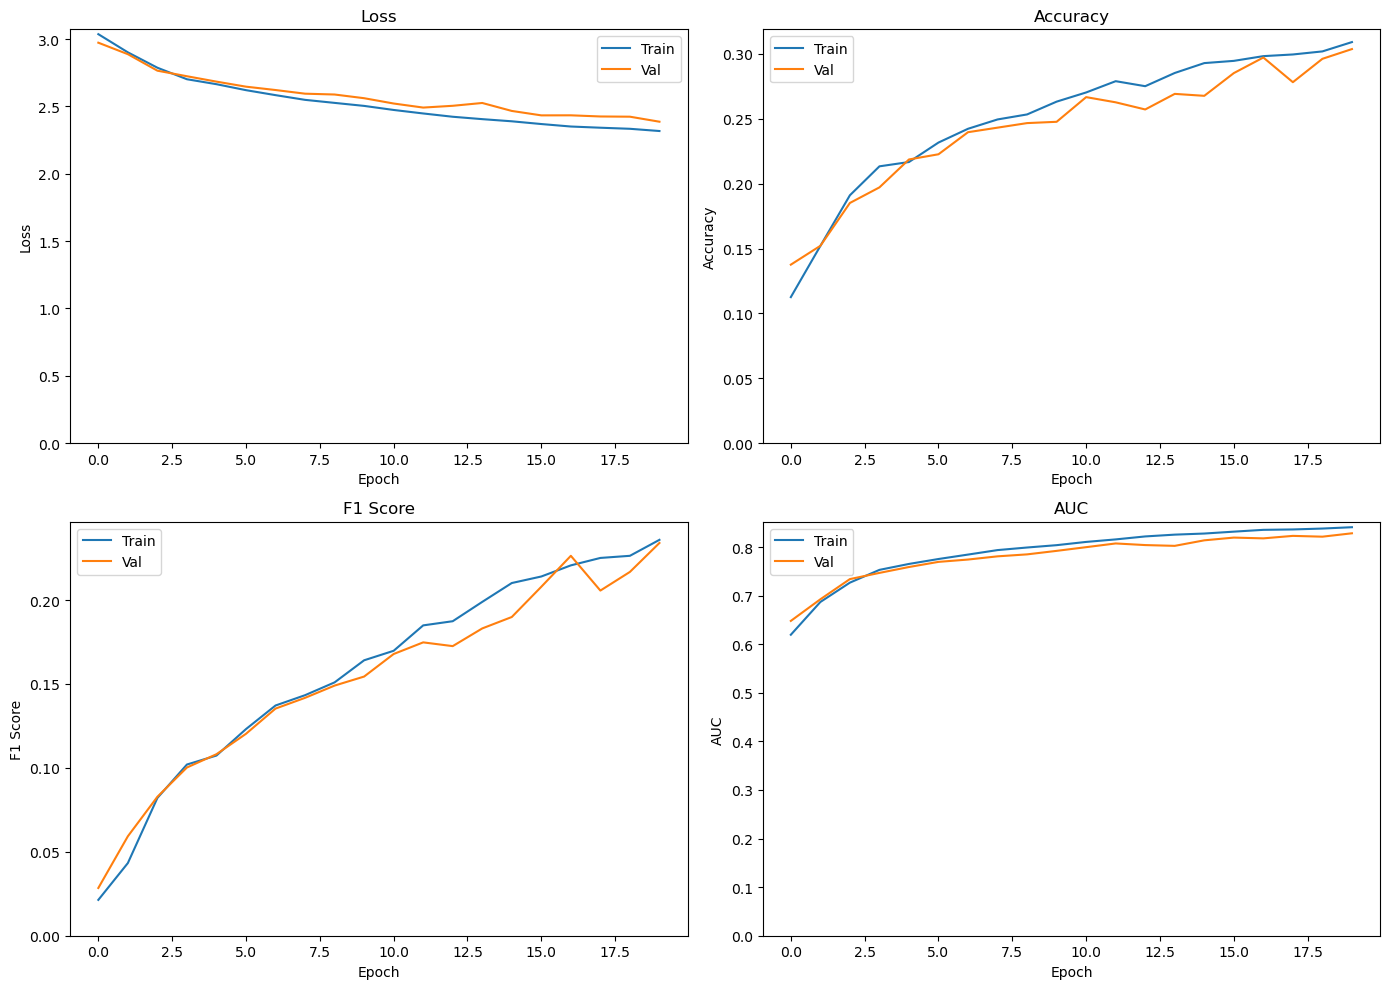

In [14]:
plot_history(Globalaveragepooling_Model_results)

In [15]:
Globalaveragepooling_Model_results2 =Globalaveragepooling_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3156 - auc: 0.8453 - f1_score: 0.2412 - loss: 2.2924 - val_accuracy: 0.3067 - val_auc: 0.8324 - val_f1_score: 0.2296 - val_loss: 2.3651
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3161 - auc: 0.8452 - f1_score: 0.2443 - loss: 2.2871 - val_accuracy: 0.3087 - val_auc: 0.8300 - val_f1_score: 0.2342 - val_loss: 2.3796
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3165 - auc: 0.8470 - f1_score: 0.2456 - loss: 2.2800 - val_accuracy: 0.2996 - val_auc: 0.8302 - val_f1_score: 0.2303 - val_loss: 2.3852
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.3219 - auc: 0.8482 - f1_score: 0.2504 - loss: 2.2712 - val_accuracy: 0.3092 - val_auc: 0.8325 - val_f1_score: 0.2390 - val_loss: 2.3730
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.3290 - auc: 0.8512 - f1_score: 0.2590 - loss: 2.2550 - val_accuracy: 0.3132 - val_auc: 0.8322 - val_f1_score: 0.2381 - va

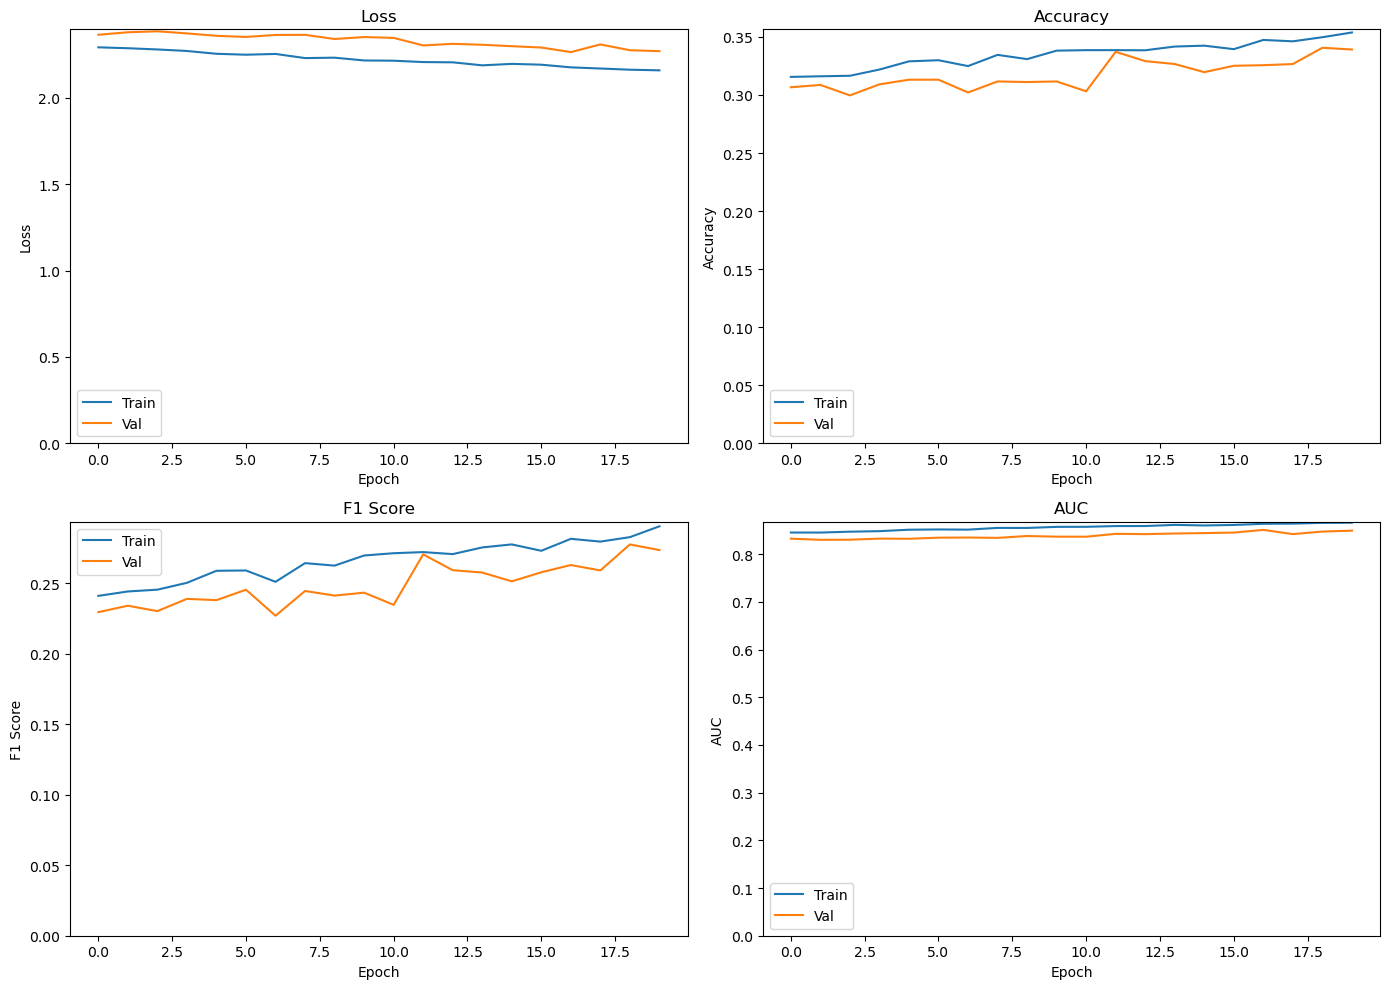

In [16]:
plot_history(Globalaveragepooling_Model_results2)

Even thought the model increased performance a bit and it is not overfitting. If we compare the score of validation of when we were using flatten, it is still higher than the one we got now.
Having this in mind, we want to increase performance while not overfitting the model.

In the next setp we will maintain Globalaveragepooling to control overfitting, but try to expand the network to see if we can increase performance

## Base Model Extended with more Convolutions

We will add more convolutional blocks with the goal of increasing performance

In [30]:
class Extended_Conv_Model(Model):
    """
    Including two more Convolutional Blocks with more filters in order to improve performance

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extended_Conv_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_3"
        )

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_4"
        )

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [31]:
Extended_Conv_Model = Extended_Conv_Model()
inputs = Input(shape=Input_shape)
_ = Extended_Conv_Model.call(inputs)
Extended_Conv_Model.summary()

Model: "Extended_Conv_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 27, 27, 40)     │         8,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 13, 13, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 11, 11, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 5, 5, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 40)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,423 (138.37 KB)

 Trainable params: 35,423 (138.37 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  # since the last model took 40 epochs to converge, we will use 40 in this one too

In [33]:
Extended_Conv_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [34]:
Extended_Conv_Model_results = Extended_Conv_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.1636 - auc: 0.6929 - f1_score: 0.0994 - loss: 2.9934 - val_accuracy: 0.1376 - val_auc: 0.6704 - val_f1_score: 0.0413 - val_loss: 2.9533
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.1725 - auc: 0.7158 - f1_score: 0.0715 - loss: 2.8267 - val_accuracy: 0.1796 - val_auc: 0.7291 - val_f1_score: 0.0799 - val_loss: 2.7896
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.2067 - auc: 0.7555 - f1_score: 0.1052 - loss: 2.6955 - val_accuracy: 0.2121 - val_auc: 0.7552 - val_f1_score: 0.1165 - val_loss: 2.7011
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.2259 - auc: 0.7750 - f1_score: 0.1263 - loss: 2.6246 - val_accuracy: 0.2206 - val_auc: 0.7707 - val_f1_score: 0.1262 - val_loss: 2.6495
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2454 - auc: 0.7916 - f1_score: 0.1519 - loss: 2.5546 - val_accuracy: 0.2261 - val_auc: 0.7810 - val_f1_score: 0.1474 - va

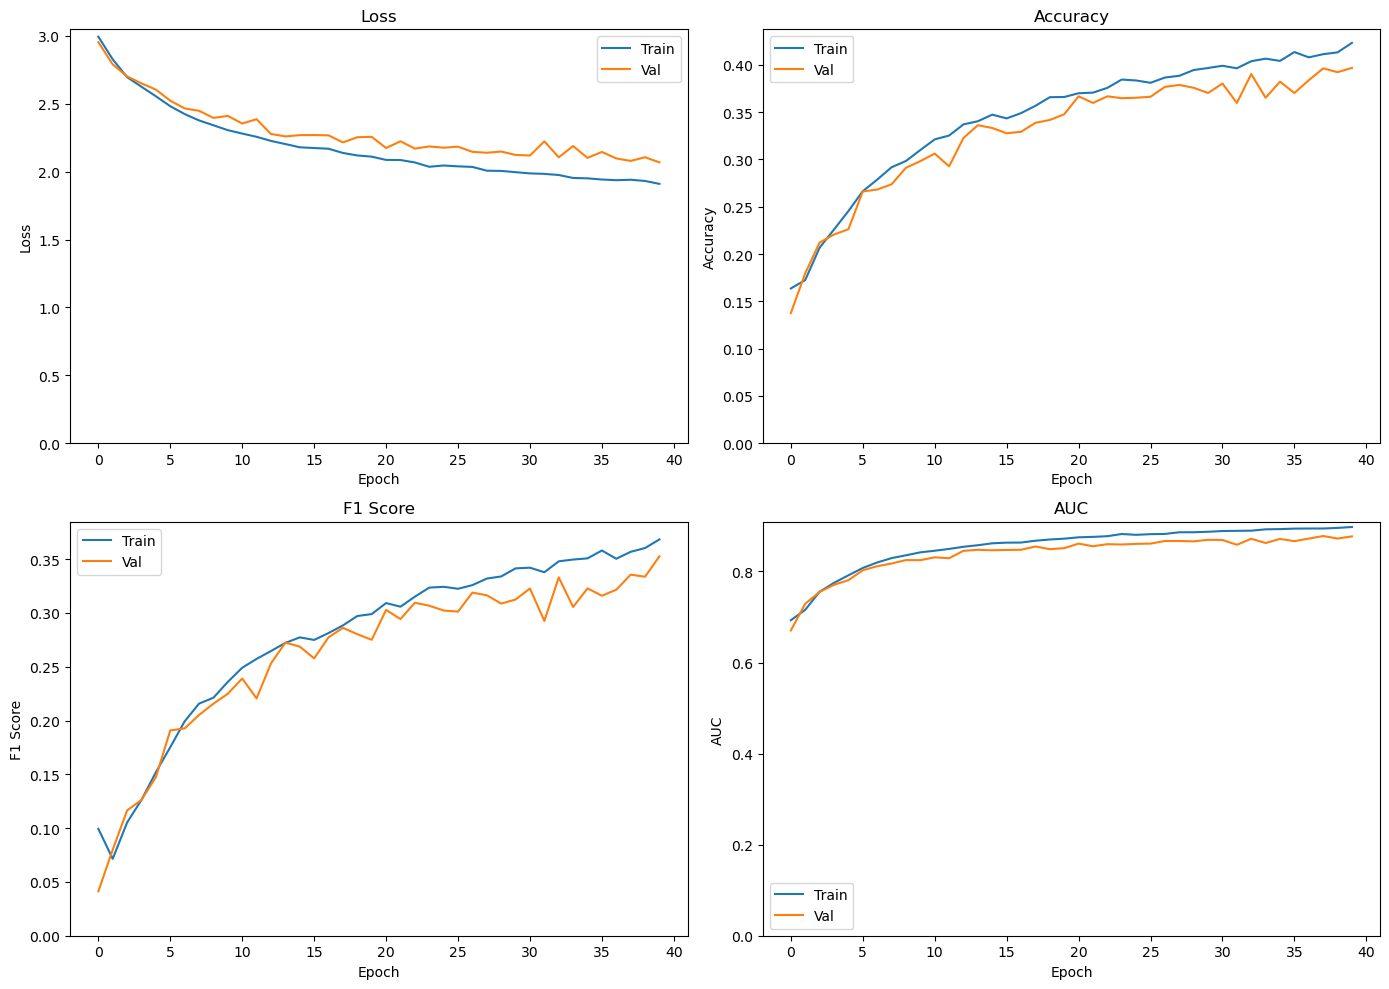

In [35]:
plot_history(Extended_Conv_Model_results)

We obtained better results in both F1 score and loss, and overfitting is well controlled. We will continue in this direction and believe the next step is to increase the number of filters in each convolutional layer. Since the dimensions of the final feature map are already 5 × 5, adding more convolutional layers would require changing the input image size. Therefore, for now, we will focus on experimenting with a higher number of filters.

### Adding More Filters to the Convolutions

In [36]:
class Extended_Conv_Model2(Model):
    """
    Experimenting more filters in each convolutional layer

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extended_Conv_Model2")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_3"
        )

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_4"
        )

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [38]:
Extended_Conv_Model2 = Extended_Conv_Model2()
inputs = Input(shape=Input_shape)
_ = Extended_Conv_Model2.call(inputs)
Extended_Conv_Model2.summary()

Model: "Extended_Conv_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 27, 27, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,415 (329.75 KB)

 Trainable params: 84,415 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [40]:
Extended_Conv_Model2.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [41]:
Extended_Conv_Model2_results = Extended_Conv_Model2.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.1789 - auc: 0.7085 - f1_score: 0.1166 - loss: 2.9617 - val_accuracy: 0.1726 - val_auc: 0.7002 - val_f1_score: 0.0650 - val_loss: 2.8634
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.1991 - auc: 0.7368 - f1_score: 0.0902 - loss: 2.7530 - val_accuracy: 0.2006 - val_auc: 0.7463 - val_f1_score: 0.1020 - val_loss: 2.7271
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.2409 - auc: 0.7746 - f1_score: 0.1341 - loss: 2.6172 - val_accuracy: 0.2216 - val_auc: 0.7688 - val_f1_score: 0.1356 - val_loss: 2.6533
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.2515 - auc: 0.7962 - f1_score: 0.1579 - loss: 2.5355 - val_accuracy: 0.2326 - val_auc: 0.7926 - val_f1_score: 0.1631 - val_loss: 2.5642
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2699 - auc: 0.8101 - f1_score: 0.1852 - loss: 2.4694 - val_accuracy: 0.2481 - val_auc: 0.7919 - val_f1_score: 0.1677 - v

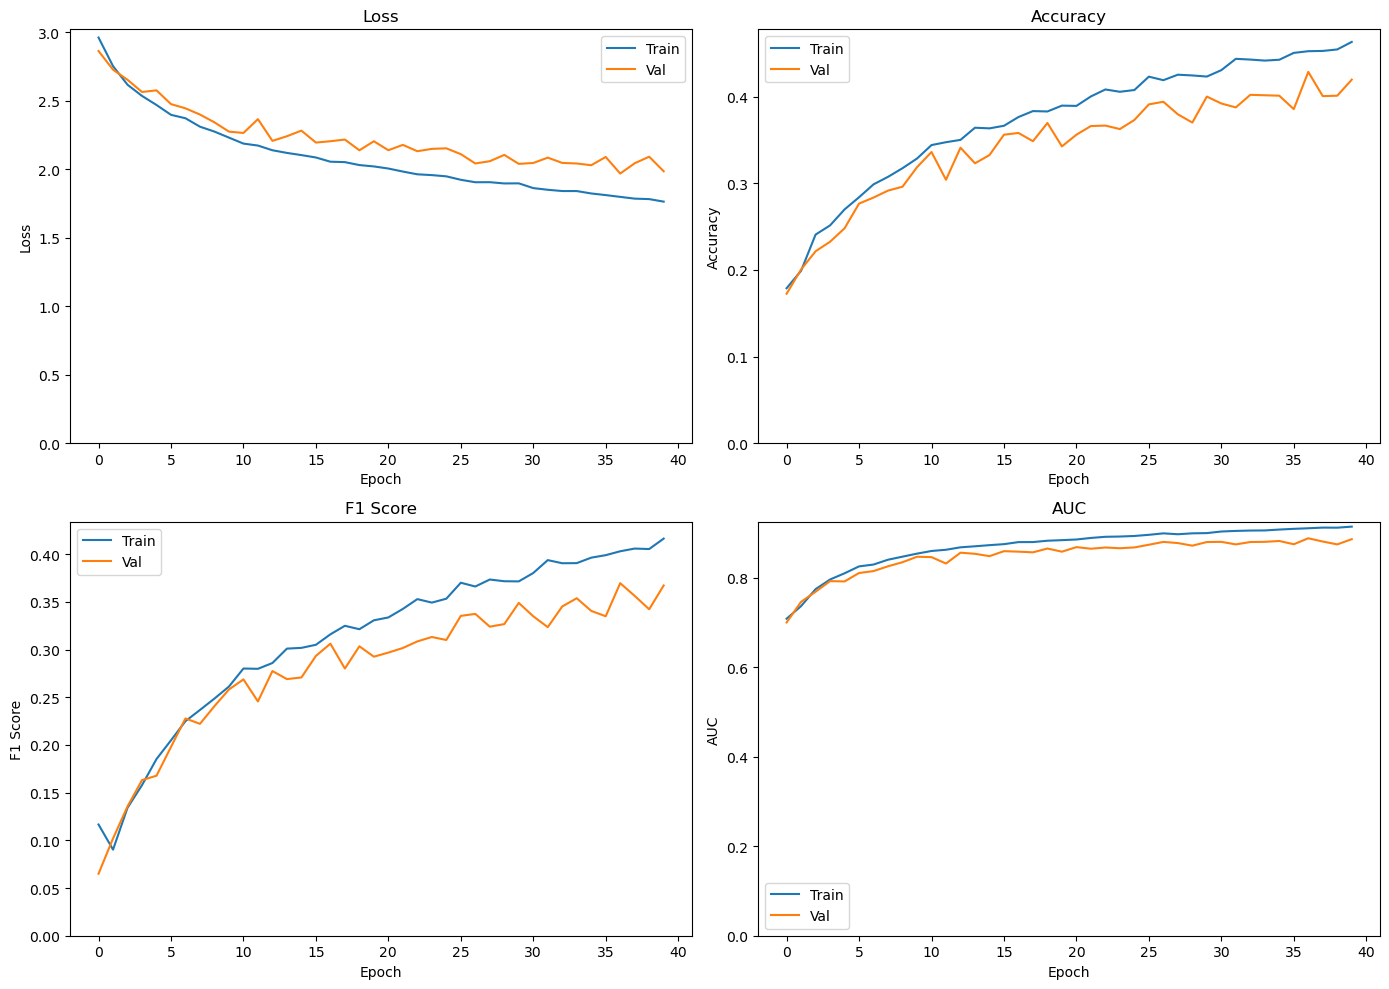

In [42]:
plot_history(Extended_Conv_Model2_results)

We continue to observe improvements in performance, and overfitting remains controlled. Next, we will add padding to the convolutional layers to better preserve and utilize information from the edges of the images, and evaluate its impact on performance.

### Extended Base Model with Padding 

In [ ]:
class Extended_Conv_Model3(Model):
    """
    Adding Padding to the Convolutions to observe the impact on performance

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extended_Conv_Model3")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_3"
        )

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_4"
        )

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [46]:
Extended_Conv_Model3 = Extended_Conv_Model3()
inputs = Input(shape=Input_shape)
_ = Extended_Conv_Model3.call(inputs)
Extended_Conv_Model3.summary()

Model: "Extended_Conv_Model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 124, 124, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 62, 62, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 62, 62, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 31, 31, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 31, 31, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,415 (329.75 KB)

 Trainable params: 84,415 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [48]:
Extended_Conv_Model3.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [49]:
Extended_Conv_Model3_results = Extended_Conv_Model3.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.1886 - auc: 0.7162 - f1_score: 0.1285 - loss: 2.9449 - val_accuracy: 0.1931 - val_auc: 0.7090 - val_f1_score: 0.0807 - val_loss: 2.8285
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.2148 - auc: 0.7447 - f1_score: 0.0978 - loss: 2.7249 - val_accuracy: 0.2036 - val_auc: 0.7585 - val_f1_score: 0.1062 - val_loss: 2.6928
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.2364 - auc: 0.7761 - f1_score: 0.1254 - loss: 2.6123 - val_accuracy: 0.2191 - val_auc: 0.7611 - val_f1_score: 0.1145 - val_loss: 2.6883
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.2484 - auc: 0.7929 - f1_score: 0.1485 - loss: 2.5493 - val_accuracy: 0.2471 - val_auc: 0.7936 - val_f1_score: 0.1580 - val_loss: 2.5561
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2726 - auc: 0.8116 - f1_score: 0.1797 - loss: 2.4646 - val_accuracy: 0.2546 - val_auc: 0.8006 - val_f1_score: 0.1784 - v

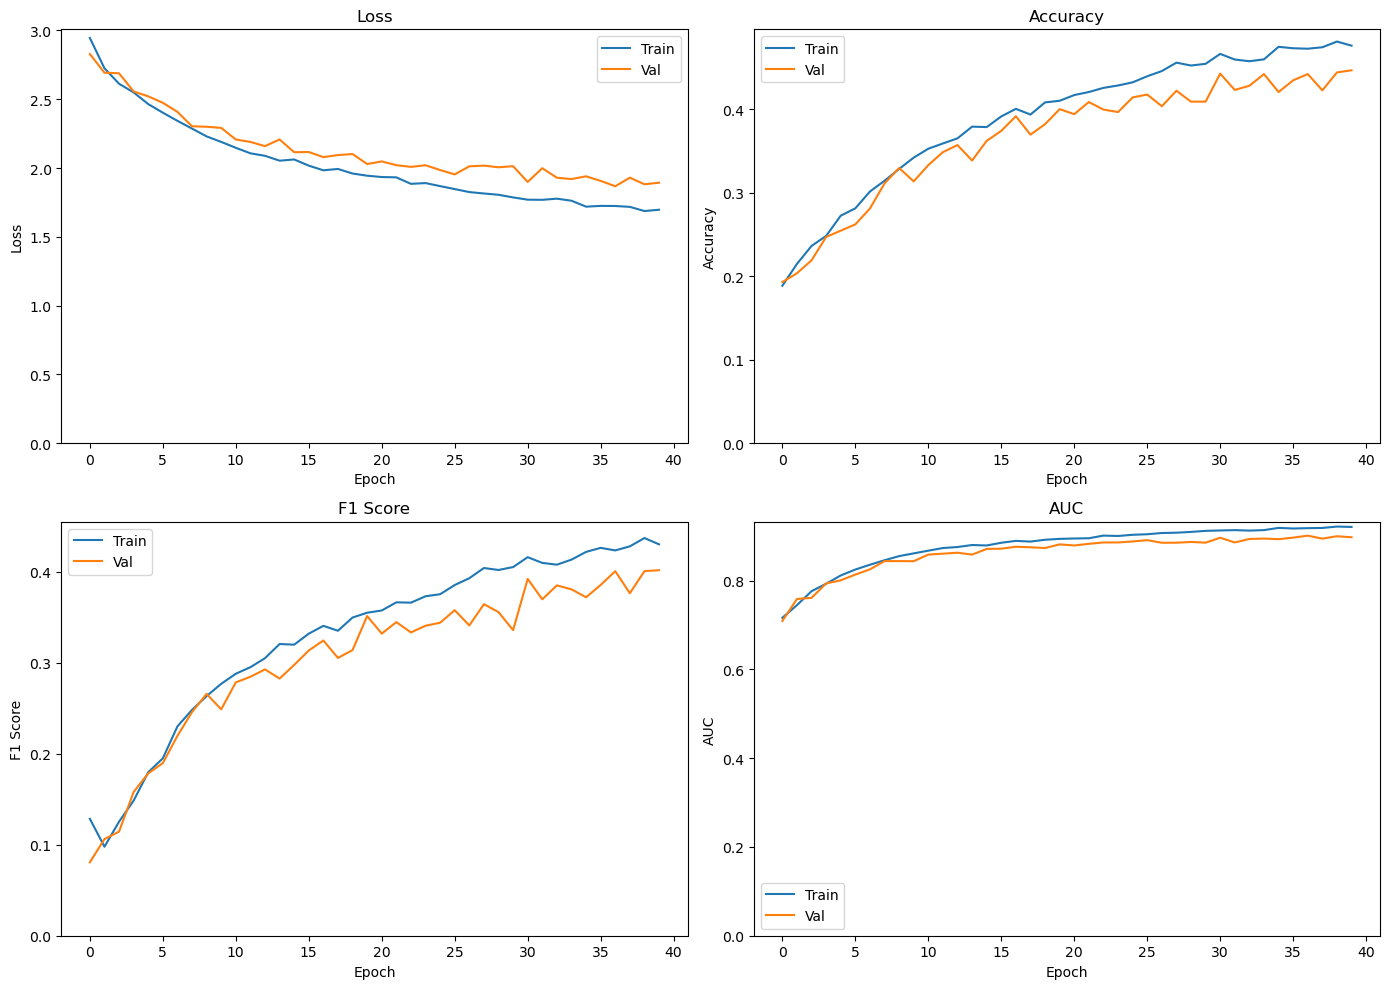

In [50]:
plot_history(Extended_Conv_Model3_results)

With padding the results improve a little compared to without padding, so it's something to consider keeping.

After some research we saw the use of batch normalization layers in convolutional blocks to improve gradient flow, so we will try it, to observe the effects in the metrics

## Base Model  with Batch Normalization

In [ ]:
class BatchNormalization_Model(Model):
    """
    Adding Batch Normalization Layers 

    """
    #Initialization
    def __init__(self):
        super().__init__(name="BatchNormalization_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_1"
        )

        self.BatchNormalization_layer1 = BatchNormalization()

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_2"
        )

        self.BatchNormalization_layer2 = BatchNormalization()

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_3"
        )

        self.BatchNormalization_layer3 = BatchNormalization()

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding= "same",
            name="conv_layer_4"
        )

        self.BatchNormalization_layer4 = BatchNormalization()

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.BatchNormalization_layer1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.BatchNormalization_layer2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.BatchNormalization_layer3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.BatchNormalization_layer4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [54]:
BatchNormalization_Model = BatchNormalization_Model()
inputs = Input(shape=Input_shape)
_ = BatchNormalization_Model.call(inputs)
BatchNormalization_Model.summary()

Model: "BatchNormalization_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 124, 124, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 124, 124, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 62, 62, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 62, 62, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 62, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 31, 31, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 31, 31, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,247 (333.00 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

In [55]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [56]:
BatchNormalization_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [57]:
BatchNormalization_Model_results = BatchNormalization_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.2685 - auc: 0.7888 - f1_score: 0.2077 - loss: 2.6744 - val_accuracy: 0.2646 - val_auc: 0.8003 - val_f1_score: 0.1901 - val_loss: 2.5239
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.3000 - auc: 0.8314 - f1_score: 0.2301 - loss: 2.3630 - val_accuracy: 0.3027 - val_auc: 0.8317 - val_f1_score: 0.2429 - val_loss: 2.3645
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.3335 - auc: 0.8558 - f1_score: 0.2715 - loss: 2.2193 - val_accuracy: 0.3327 - val_auc: 0.8546 - val_f1_score: 0.2747 - val_loss: 2.2326
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.3665 - auc: 0.8726 - f1_score: 0.3067 - loss: 2.1084 - val_accuracy: 0.3427 - val_auc: 0.8598 - val_f1_score: 0.2761 - val_loss: 2.2059
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.3935 - auc: 0.8833 - f1_score: 0.3350 - loss: 2.0241 - val_accuracy: 0.3767 - val_auc: 0.8788 - val_f1_score: 0.3082

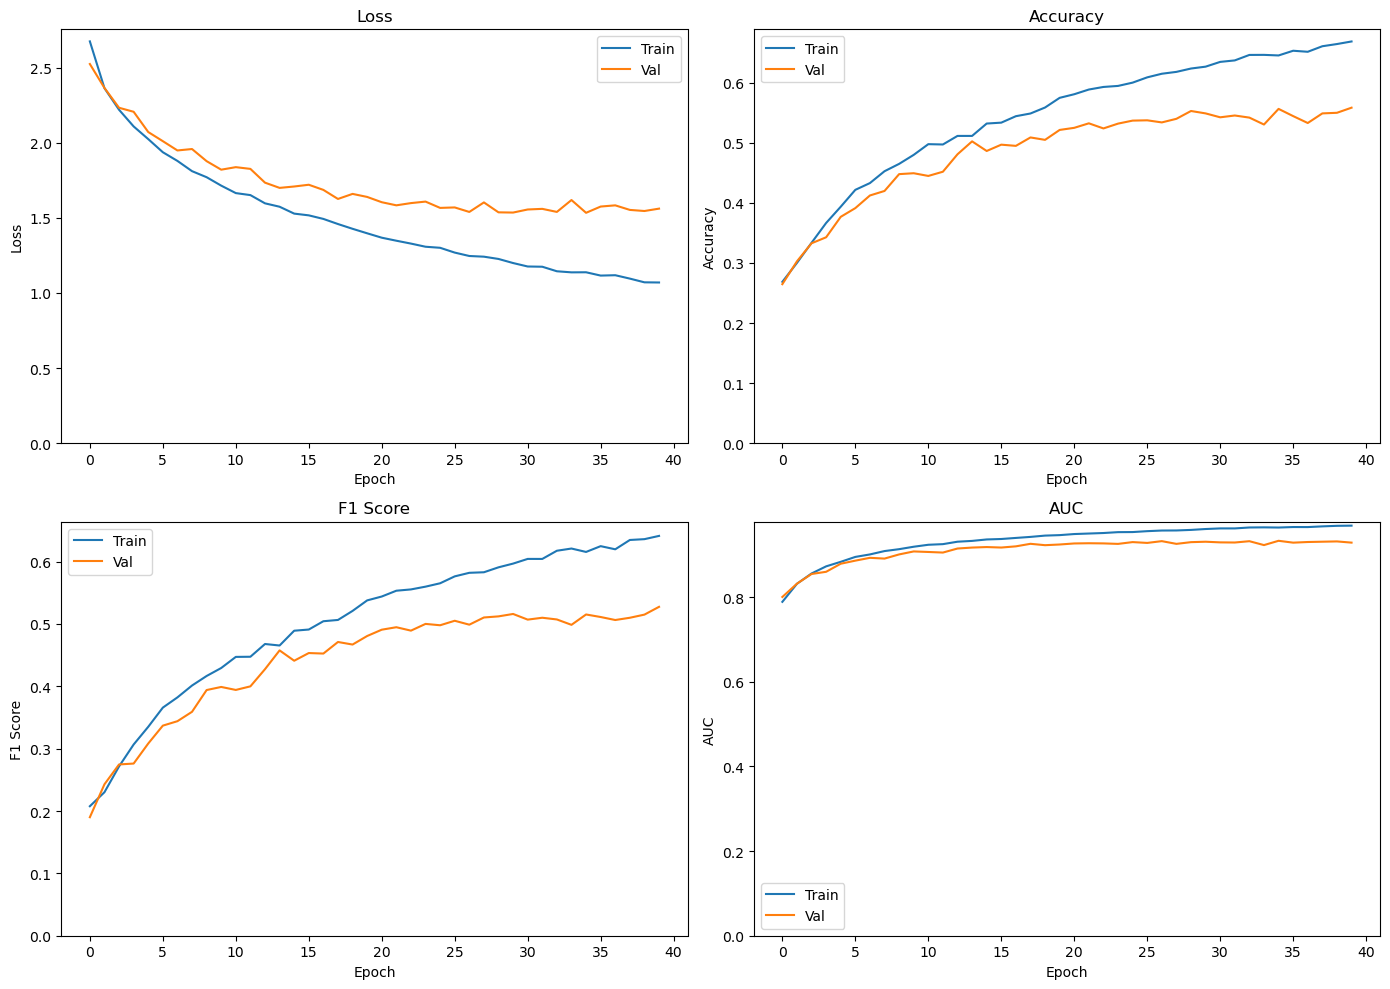

In [58]:
plot_history(BatchNormalization_Model_results)

Based on the results, we can see that the scores improved considerably. Overfitting increased slightly, but not dramatically.

We believe we have already reached a good solution for a model built from scratch, so next we will try new approaches to see how the model’s performance responds.

### Adding the Batch normalization layer before the activation function

After some research we discovered that the batch normalization layers should be added before the activation function and not after, so we decided to try it out

In [15]:
class BatchNormalization2_Model(Model):
    """
    Adding Batch Normalization Layers (before activation function)

    """
    #Initialization
    def __init__(self):
        super().__init__(name="BatchNormalization_Model2")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_1"
        )

        self.BatchNormalization_layer1 = BatchNormalization()

        self.activation_1 = Activation(activation="relu")

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_2"
        )

        self.BatchNormalization_layer2 = BatchNormalization()

        self.activation_2 = Activation(activation="relu")

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_3"
        )

        self.BatchNormalization_layer3 = BatchNormalization()

        self.activation_3 = Activation(activation="relu")

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_4"
        )

        self.BatchNormalization_layer4 = BatchNormalization()

        self.activation_4 = Activation(activation="relu")

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.BatchNormalization_layer1(x)
        x = self.activation_1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.BatchNormalization_layer2(x)
        x = self.activation_2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.BatchNormalization_layer3(x)
        x = self.activation_3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.BatchNormalization_layer4(x)
        x = self.activation_4(x)
        x = self.max_pool_layer_4(x)                              
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [17]:
BatchNormalization2_Model = BatchNormalization2_Model()
inputs = Input(shape=Input_shape)
_ = BatchNormalization2_Model.call(inputs)
BatchNormalization2_Model.summary()

Model: "BatchNormalization_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 124, 124, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 124, 124, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 124, 124, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 62, 62, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 62, 62, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 62, 62, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 62, 62, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 31, 31, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 31, 31, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 23)             │         2,32

 Total params: 85,247 (333.00 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

In [ ]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [19]:
BatchNormalization2_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [20]:
BatchNormalization2_Model_results = BatchNormalization2_Model.fit(
    train_df,
    validation_data= val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.2662 - auc: 0.7927 - f1_score: 0.2090 - loss: 2.7077 - val_accuracy: 0.2411 - val_auc: 0.7860 - val_f1_score: 0.1672 - val_loss: 2.5887
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.2868 - auc: 0.8232 - f1_score: 0.2153 - loss: 2.4074 - val_accuracy: 0.3067 - val_auc: 0.8273 - val_f1_score: 0.2369 - val_loss: 2.3893
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.3311 - auc: 0.8504 - f1_score: 0.2653 - loss: 2.2519 - val_accuracy: 0.3302 - val_auc: 0.8461 - val_f1_score: 0.2655 - val_loss: 2.2781
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.3530 - auc: 0.8667 - f1_score: 0.2901 - loss: 2.1515 - val_accuracy: 0.3657 - val_auc: 0.8607 - val_f1_score: 0.2968 - val_loss: 2.1806
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.3750 - auc: 0.8785 - f1_score: 0.3165 - loss: 2.0686 - val_accuracy: 0.3642 - val_auc: 0.8705 - val_f1_score: 0.2904

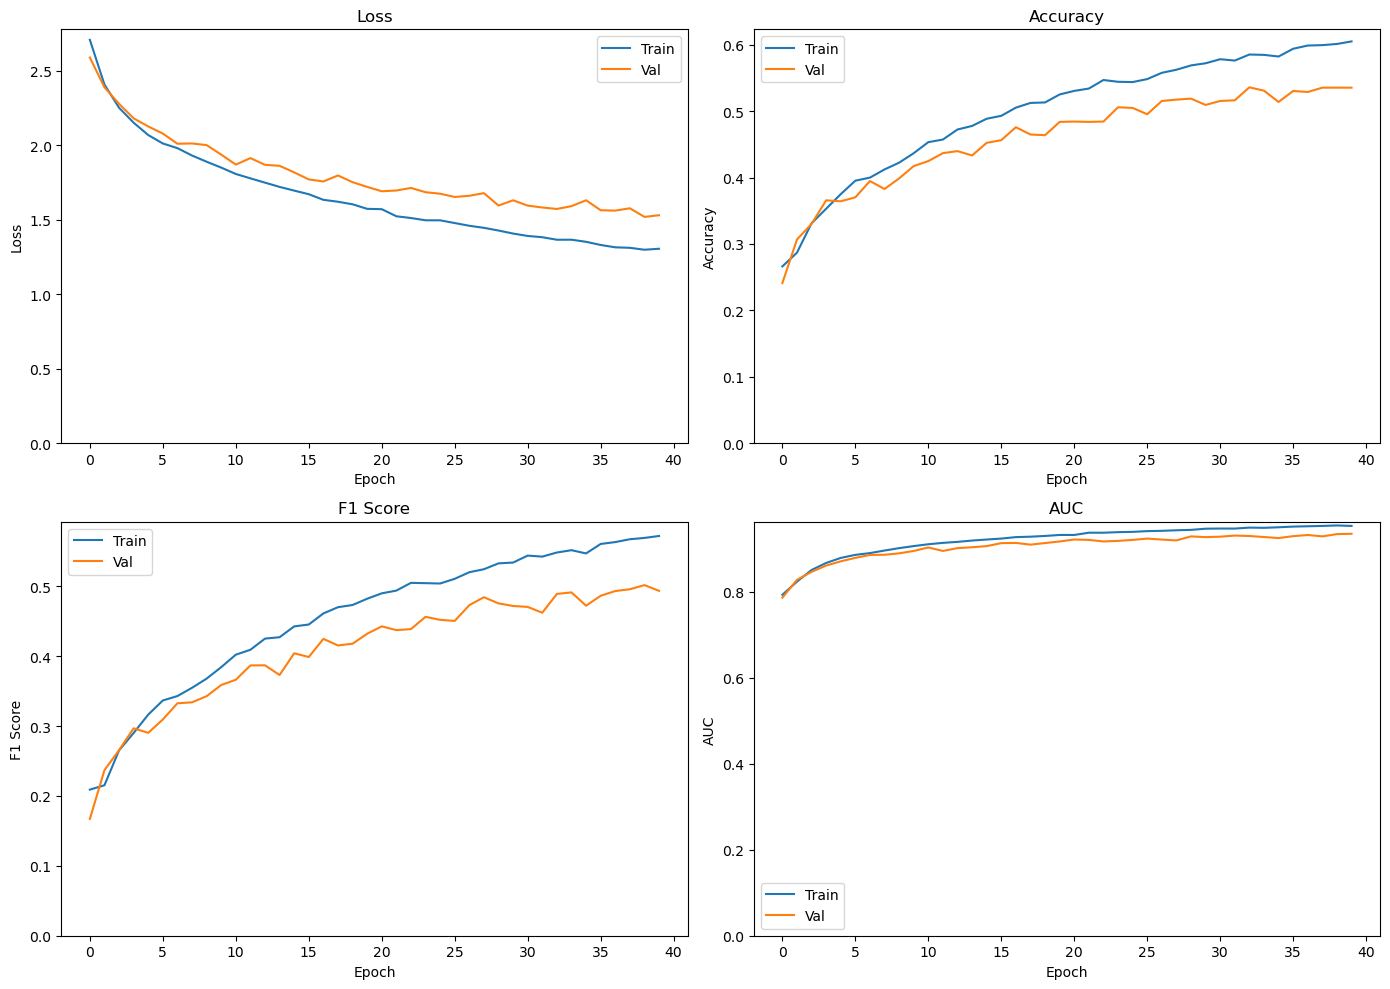

In [21]:
plot_history(BatchNormalization2_Model_results)

After testing batch normalization layers before the activation functions, the results were not significantly different. The validation F1 score reached 0.5, similar to the previous model where batch normalization was applied after the activation function. However, the training F1 score in this model was 0.57, compared to 0.64 in the previous one, indicating less overfitting. Based on this and the fact and that it is theoretically more appropriate, we will keep the batch normalization layers before the activation functions.

## Base Model with Deeper Classification Head

Since in a previous step we extended the convolutional part of our network to improve performance, we will now focus on improving the classifier to observe its impact on overall performance. We expect some increase in overfitting, so to account for that we will increase dropout rate to 0.4

In [22]:
class Extra_Dense_Model(Model):
    """
    Expanding the Classification Head

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Extra_Dense_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_1"
        )

        self.BatchNormalization_layer1 = BatchNormalization()

        self.activation_1 = Activation(activation="relu")

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=40,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_2"
        )

        self.BatchNormalization_layer2 = BatchNormalization()

        self.activation_2 = Activation(activation="relu")

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        #Third Convolutional Block
        self.Conv3 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_3"
        )

        self.BatchNormalization_layer3 = BatchNormalization()

        self.activation_3 = Activation(activation="relu")

        #Third Pooling Layer
        self.max_pool_layer_3 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_3"
        )


        #Fourth Convolutional Block
        self.Conv4 = Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding= "same",
            name="conv_layer_4"
        )

        self.BatchNormalization_layer4 = BatchNormalization()

        self.activation_4 = Activation(activation="relu")

        #Fourth Pooling Layer
        self.max_pool_layer_4 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_4"
        )

        self.Globalaveragepooling_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(258, activation="relu")
        self.Drop_out =Dropout(rate=0.4)  #Higher drop out to control overfitting
        self.Dense_2 = Dense(100, activation="relu")
        self.Dense_3 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.BatchNormalization_layer1(x)
        x = self.activation_1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.BatchNormalization_layer2(x)
        x = self.activation_2(x)
        x = self.max_pool_layer_2(x) 
        x = self.Conv3(x)
        x = self.BatchNormalization_layer3(x)
        x = self.activation_3(x)
        x = self.max_pool_layer_3(x)
        x = self.Conv4(x)
        x = self.BatchNormalization_layer4(x)
        x = self.activation_4(x)
        x = self.max_pool_layer_4(x)                                
        x = self.Globalaveragepooling_layer(x)                                     
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)
        x = self.Dense_3(x)

        return x

In [23]:
Extra_Dense_Model = Extra_Dense_Model()
inputs = Input(shape=Input_shape)
_ = Extra_Dense_Model.call(inputs)
Extra_Dense_Model.summary()

Model: "Extra_Dense_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 124, 124, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 124, 124, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 124, 124, 40)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 62, 62, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 62, 62, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 62, 62, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 62, 62, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 31, 31, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 31, 31, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 258)            │        16,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 258)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        25,90

 Total params: 121,417 (474.29 KB)

 Trainable params: 121,001 (472.66 KB)

 Non-trainable params: 416 (1.62 KB)

In [24]:
optimizer =Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 40  

In [25]:
Extra_Dense_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [26]:
Extra_Dense_Model_results = Extra_Dense_Model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.2730 - auc: 0.7920 - f1_score: 0.2063 - loss: 2.7114 - val_accuracy: 0.2681 - val_auc: 0.7886 - val_f1_score: 0.1798 - val_loss: 2.5567
Epoch 2/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.2941 - auc: 0.8257 - f1_score: 0.2101 - loss: 2.3921 - val_accuracy: 0.3017 - val_auc: 0.8355 - val_f1_score: 0.2246 - val_loss: 2.3436
Epoch 3/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.3314 - auc: 0.8549 - f1_score: 0.2623 - loss: 2.2279 - val_accuracy: 0.3342 - val_auc: 0.8501 - val_f1_score: 0.2559 - val_loss: 2.2516
Epoch 4/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.3636 - auc: 0.8704 - f1_score: 0.2963 - loss: 2.1256 - val_accuracy: 0.3452 - val_auc: 0.8574 - val_f1_score: 0.2842 - val_loss: 2.2100
Epoch 5/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.3815 - auc: 0.8808 - f1_score: 0.3184 - loss: 2.0512 - val_accuracy: 0.3512 - val_auc: 0.8649 - val_f1_score: 0.2972

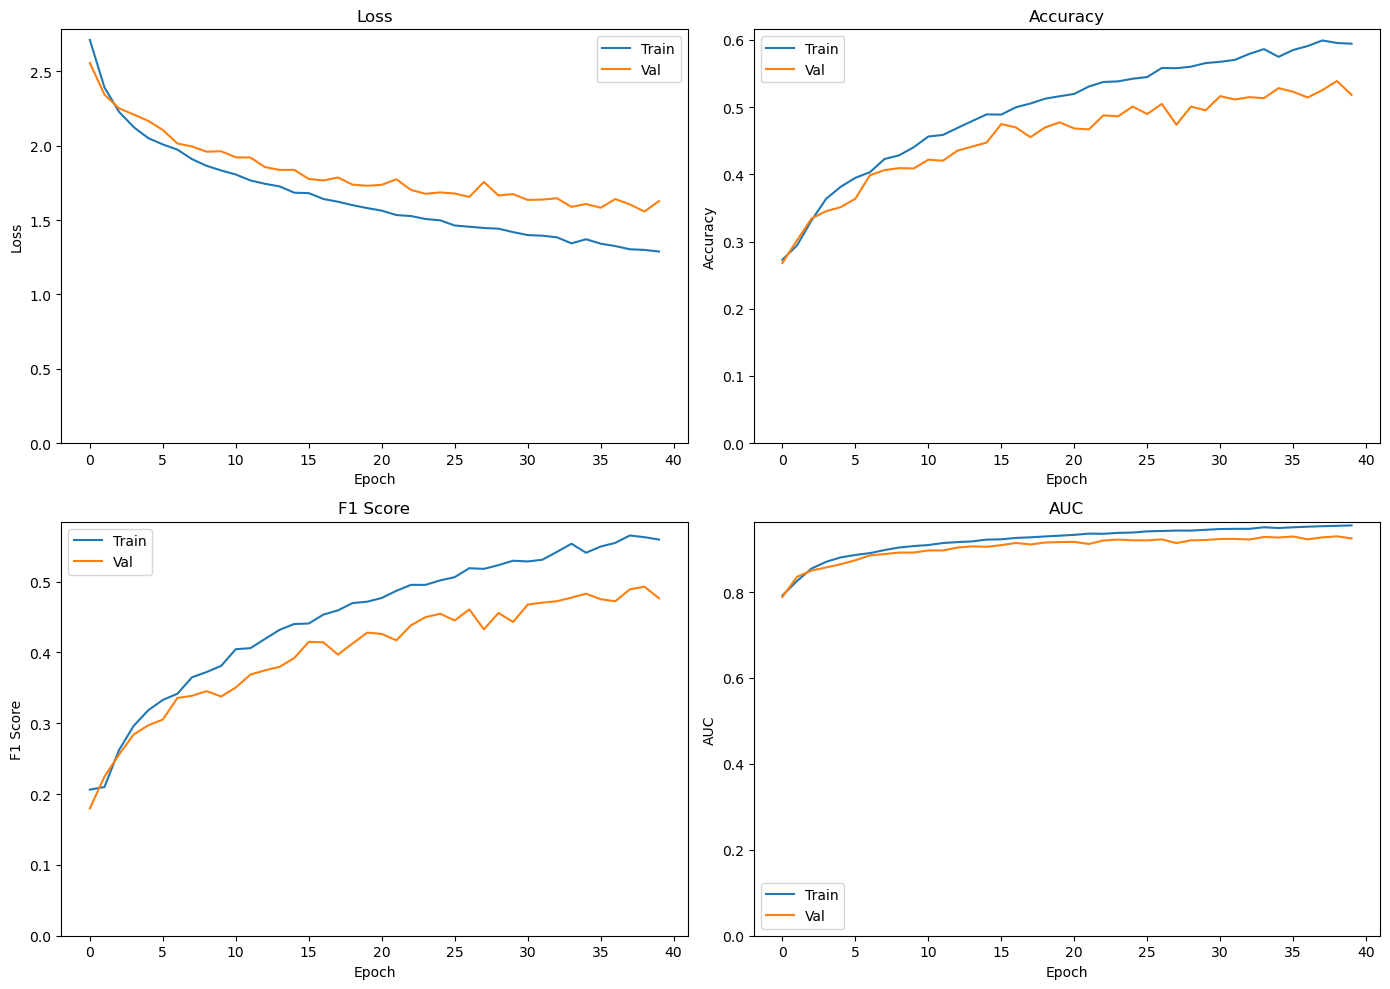

In [27]:
plot_history(Extra_Dense_Model_results)



The results were very similar to those obtained without the extended classification head (practically identical). Therefore, we conclude that it is not worth adding more dense layers, as this increases computational cost and requires a higher dropout rate to control overfitting.

In [28]:
BatchNormalization2_Model.save('Base_Model.keras')

## Increasing Strieds and removing Pooling